# Кейс по моделированию

В задачах кредитного скоринга, предсказания дефолта самым важным признаком служит заработная плата клиента. Но не всегда она известна.
Требуется решить задачу бинарной классификации, а именно построить алгоритм, определяющий, превысит ли средний заработок человека порог $50k

In [49]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

#### Состав датасета

1) age (Возраст): continuous. 

2) workclass (Информация о работе): Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 

3) fnlwgt (Вещественный признак - анонимен): continuous. 

4) education (Образование): Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 

5) education-num: continuous. 

6) marital-status (Семейное положение): Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 

7) occupation (Род деятельности): Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 

8) relationship (Статус в семье): Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 

9) race (Раса): White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black. 

10) sex (Пол): Female, Male. 

11) capital-gain (Размер капитала): continuous. 

12) capital-loss (Фича на основе капитала): continuous. 

13) hours-per-week (Сколько часов в неделю работает): continuous.

14) >50K,<=50K (Целевой признак/таргет)

#### Скачиваем данные

In [50]:
# В данной таблице NaNы заполнены значком '?', заменяем на проспуски с помощью параметра "na_values"

data_adult = pd.read_csv("3_data_adult_v2.csv", na_values='?')
data_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K


In [51]:
# Выведем информацию о колонках
data_adult.info()

<class 'pandas.DataFrame'>
RangeIndex: 15280 entries, 0 to 15279
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             15280 non-null  int64
 1   workclass       14413 non-null  str  
 2   fnlwgt          15280 non-null  int64
 3   education       15280 non-null  str  
 4   education-num   15280 non-null  int64
 5   marital-status  15280 non-null  str  
 6   occupation      14409 non-null  str  
 7   relationship    15280 non-null  str  
 8   race            15280 non-null  str  
 9   sex             15280 non-null  str  
 10  capital-gain    15280 non-null  int64
 11  capital-loss    15280 non-null  int64
 12  hours-per-week  15280 non-null  int64
 13  >50K,<=50K      15280 non-null  str  
dtypes: int64(6), str(8)
memory usage: 1.6 MB


### 1. Анализ

In [52]:
# Посчитаем количество пропусков в каждой колонке
print(data_adult.shape)
data_adult.isnull().sum()

(15280, 14)


age                 0
workclass         867
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        871
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
>50K,<=50K          0
dtype: int64

In [53]:
# Удаление из выборки всех объектов с пропусками
data_adult.dropna(inplace=True)
print(data_adult.shape)
data_adult.isnull().sum()

# Количество наблюдений уменьшилось на 871

(14409, 14)


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
>50K,<=50K        0
dtype: int64

In [54]:
# Выделение целевой переменной и ее преобразование к бинарному формату
target_col = data_adult['>50K,<=50K'].apply(lambda x: 1 if x == '>50K' else 0)
data_adult.drop(['>50K,<=50K'], axis=1, inplace=True)

>50K,<=50K
0    0.743841
1    0.256159
Name: proportion, dtype: float64


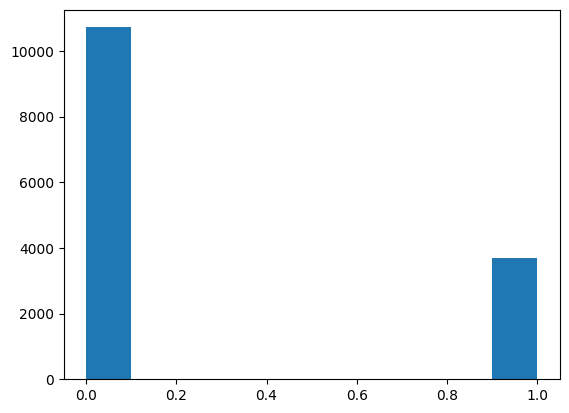

In [55]:
print(target_col.value_counts(normalize=True))
plt.hist(target_col);

Классы распределены неравномерно: 74.4% против 25.6%. Доминирует класс с низким доходом

workclass
Private             0.735721
Self-emp-not-inc    0.085919
Local-gov           0.069193
State-gov           0.041918
Self-emp-inc        0.036783
Federal-gov         0.030051
Without-pay         0.000416
Name: proportion, dtype: float64

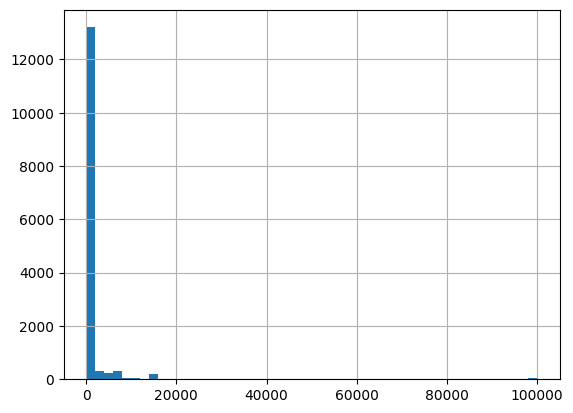

In [56]:
# Посмотрим распределение признака capital-gain и процентного соотношения категорий в колонке workclass
data_adult['capital-gain'].hist(bins=50); #Гистограмма показывает, что размер капитала сконцентрирован около нуля 
data_adult['workclass'].value_counts(normalize=True) # Максимум (74%) наблюдений занимает категория 'Private', а минимум (0,04%) - категория 'Without-Pay' 

Размер капитала сильно сконцентрирован около нуля. Максимум (73,6%) наблюдений - категория 'Private', а минимум (0,042%) - категория 'Without-Pay'

In [57]:
data_adult['capital-gain'].median()

np.float64(0.0)

Подтверждает концентрацию данных около нуля (более чем у половины людей прирост капитала отсутствует)

### 2. Категориальные признаки

Cреди признаков есть категориальные.
Выделим 3 переменные (cat - список категориальных признаков, num - список вещественных признаков, target - таргет (строка)), закодируем их и выберем признаки для обучения

In [58]:
data_adult.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
dtype: object

In [59]:
cat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
num = ['age', 'fnlwgt', 'education-num','capital-gain','capital-loss', 'hours-per-week']
target = 'target'

In [60]:
data_adult = pd.get_dummies(data_adult, columns=cat, drop_first=True, dtype=int, sparse=True)
data_adult.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,34,284843,9,594,0,60,1,0,0,0,...,1,0,0,0,0,0,1,0,0,1
1,40,190290,10,0,0,40,0,1,0,0,...,1,0,0,0,0,0,0,0,1,1
2,36,177858,13,0,0,40,1,0,0,0,...,0,0,1,0,0,0,0,0,1,1
3,22,184756,10,0,0,30,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,47,149700,13,15024,0,40,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1


In [61]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
data_adult.columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Local-gov', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate',
       'education_HS-grad', 'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-clea

In [63]:
from sklearn.feature_selection import RFE #для рекурсивного удаления признаков
from sklearn.linear_model import LogisticRegression

cols_to_drop = ['target'] # Смотрим, что нельзя использовать как признак

train_columns = data_adult.columns.difference(cols_to_drop) # формируем список всех доступных признаков

# Модель, RFE
model = LogisticRegression(max_iter=1000)
selector = RFE(estimator=model, n_features_to_select=15) # топ-15 лучших признаков
selector.fit(data_adult[train_columns], target_col)

selected_features = train_columns[selector.support_] # финальный список лучших признаков

print("Отобранные признаки:")
print(selected_features)

c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed

Отобранные признаки:
Index(['education_1st-4th', 'education_5th-6th', 'education_7th-8th',
       'education_Prof-school', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse', 'occupation_Exec-managerial',
       'occupation_Handlers-cleaners', 'occupation_Other-service',
       'occupation_Prof-specialty', 'occupation_Tech-support',
       'relationship_Other-relative', 'relationship_Own-child',
       'relationship_Wife', 'sex_Male'],
      dtype='str')


In [64]:
data_adult[num].columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='str')

In [65]:
for i in data_adult[num].columns:
    print(data_adult[i].corr(target_col))

0.23429604087757086
-0.006876605427065549
0.33297272371041126
0.22028875241444223
0.15039329826616196
0.230712469699857


In [66]:
num.remove('fnlwgt') 
num.remove('capital-loss')

In [67]:
selected_features

Index(['education_1st-4th', 'education_5th-6th', 'education_7th-8th',
       'education_Prof-school', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse', 'occupation_Exec-managerial',
       'occupation_Handlers-cleaners', 'occupation_Other-service',
       'occupation_Prof-specialty', 'occupation_Tech-support',
       'relationship_Other-relative', 'relationship_Own-child',
       'relationship_Wife', 'sex_Male'],
      dtype='str')

In [68]:
data_adult = pd.concat([data_adult[num], data_adult[selected_features]], axis=1)
data_adult.head()

,age,education-num,capital-gain,hours-per-week,education_1st-4th,education_5th-6th,education_7th-8th,education_Prof-school,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,occupation_Exec-managerial,occupation_Handlers-cleaners,occupation_Other-service,occupation_Prof-specialty,occupation_Tech-support,relationship_Other-relative,relationship_Own-child,relationship_Wife,sex_Male
0,34,9,594,60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,40,10,0,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,36,13,0,40,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1
3,22,10,0,30,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,47,13,15024,40,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1


### 3. Нормализация данных

Проведем анализ шкал признаков (определеим, какого порядка вещественные признаки)

In [69]:
data_adult[num].describe()

,age,education-num,capital-gain,hours-per-week
count,14409.000000,14409.000000,14409.000000,14409.000000
mean,38.507461,10.151641,1072.242557,40.877646
std,13.112785,2.558609,7107.232268,12.036462
min,17.000000,1.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,99.000000


1. Шкалы признаков имеют разный порядок величин (разброс значений и стандартные отклонения существенно отличаются).
2. Проблема: признаки с большим диапазоном значений начинают доминировать, искажая вклад остальных признаков.
3. Влияет на алгоритмы, использующие расстояния (kNN, SVM, k-Means) и градиентный спуск (Линейная/Логистическая регрессия, Нейросети).
4. Не влияет на древовидные алгоритмы (Decision Tree, Random Forest, Gradient Boosting), так как они делают разбиения по пороговым значениям, а не по расстояниям.

Далее, масштабируем данные и используем масштабированные признаки

In [70]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler(with_mean=True, with_std=True)

data_adult[num]=std_scale.fit_transform(data_adult[num])
data_adult.head()

,age,education-num,capital-gain,hours-per-week,education_1st-4th,education_5th-6th,education_7th-8th,education_Prof-school,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,occupation_Exec-managerial,occupation_Handlers-cleaners,occupation_Other-service,occupation_Prof-specialty,occupation_Tech-support,relationship_Other-relative,relationship_Own-child,relationship_Wife,sex_Male
0,-0.343757,-0.450120,-0.067292,1.588757,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0.113827,-0.059269,-0.150872,-0.072918,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,-0.191229,1.113284,-0.150872,-0.072918,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1
3,-1.258927,-0.059269,-0.150872,-0.903756,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.647676,1.113284,1.963105,-0.072918,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1


In [71]:
X = data_adult.copy() # Наши признаки
y = target_col.copy() # Наша колонка таргета

### 4. Валидация

В нашем случае будем валидироваться с помощью KFold + сохранение баланса классов в каждом "фолде" с помощью StratifiedKFold из sklearn.model_selection

In [72]:
# Основные подходы к валидации:
# 1. Hold-out (train/test split):
#    + быстро и просто.
#    - высокая дисперсия оценки (зависит от случайного разбиения); риск переобучения на конкретный тест
#
# 2. K-Fold Cross-Validation:
#    + более надежная и устойчивая оценка качества модели; эффективное использование данных
#    - Вычислительно затратно т.к. модель обучается K раз
#
# 3. Time Series Split для временных рядов:
#    + учитывает хронологический порядок
#    - нельзя перемешивать данные, сложность в вычислениях
#
# 4. Train/Val/Test split:
#    + позволяет независимо настраивать гиперпараметры (на Val) и финально оценивать модель (на Test).
#    - требует большого объема данных, чтобы каждая выборка была репрезентативной.

# Преимущество StratifiedKFold перед обычным KFold: он сохраняет исходное распределение классов в каждом фолде.

### 5. Выбор алгоритма и оптимизация

При подборе алгоритма будем варьировать не один параметр, а несколько в каждом алгоритме.

Выберем 3 алгоритма:

 - kNN
 - SGD Linear Classifier
 - RandomForest

### 5.1 kNN

- Инициализацируем дефолтную модель и GridSearchCV для подбора гиперпараметров
- Подберем наилучшие параметры для модели с помощью GridSearchCV (число соседей (**n_neighbors**) перебираем в диапазоне от 0 до 50, метрику (**metric**) перебираем из \['minkowski', 'euclidean', 'chebyshev', 'manhattan'\])
- Построим график зависимости качества ROC-AUC от параметров с доверительным интервалом (и посмотрим параметры лучшей модели с помощью gsCV.best_params_)

In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [74]:
# Инициализация дефолтной модели KNN
knn_model = KNeighborsClassifier()

# Перебор параметров модели
params_knn = {'n_neighbors': list(range(1, 51)),
    'metric': ['minkowski', 'euclidean', 'chebyshev', 'manhattan']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gsCV = GridSearchCV(knn_model,
    params_knn,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1)

gsCV.fit(X, y)

print("Лучшие параметры:", gsCV.best_params_)
print("Лучший ROC-AUC:", gsCV.best_score_)

Лучшие параметры: {'metric': 'minkowski', 'n_neighbors': 50}
Лучший ROC-AUC: 0.8969584554626888


c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [75]:
# import pandas as pd
# import matplotlib.pyplot as plt

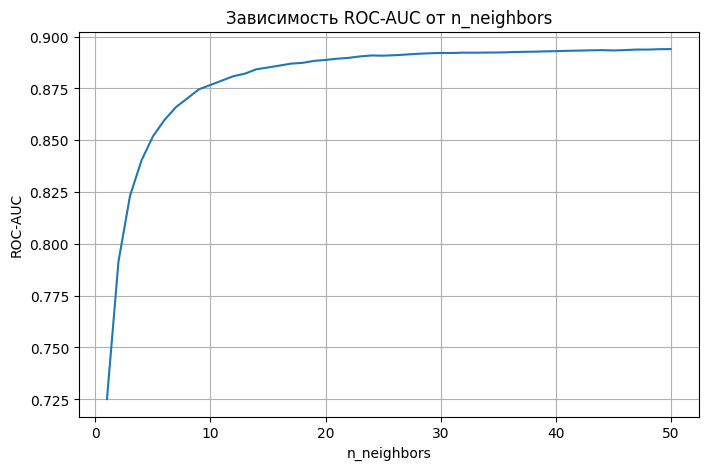

In [76]:
results_knn = pd.DataFrame(gsCV.cv_results_)

scores_neighbors = results_knn.groupby('param_n_neighbors')['mean_test_score'].mean()

plt.figure(figsize=(8, 5))
plt.plot(scores_neighbors.index, scores_neighbors.values)
plt.xlabel('n_neighbors')
plt.ylabel('ROC-AUC')
plt.title('Зависимость ROC-AUC от n_neighbors')
plt.grid()
plt.show()

ROC-AUC увеличивается с ростом n_neighbors, причем основной прирост качества наблюдается при переходе от малых значений к примерно 10–15 соседям. Далее кривая постепенно выходит на плато: увеличение числа соседей продолжает улучшать результат, но прирост становится незначительным. Максимальное значение ROC-AUC на исследуемом диапазоне достигается при n_neighbors = 50 и составляет около 0.897.

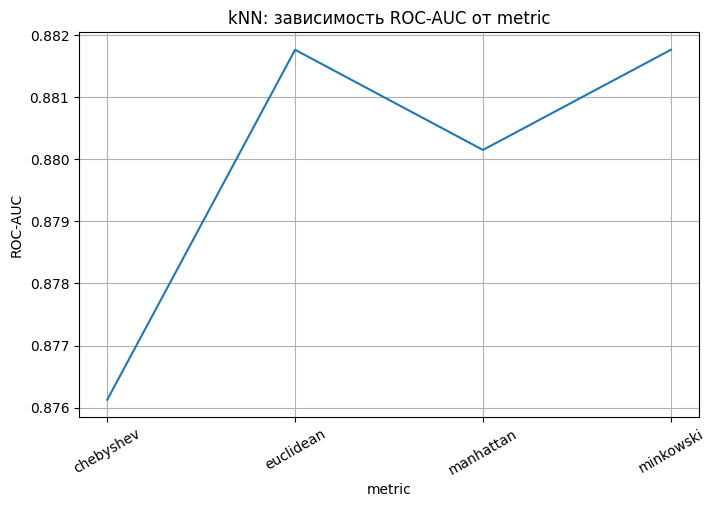

In [77]:
scores_metric = results_knn.groupby('param_metric')['mean_test_score'].mean()

xTicks = scores_metric.index.tolist()
x_knn = range(len(xTicks))

plt.figure(figsize=(8, 5))
plt.plot(x_knn, scores_metric.values)

plt.xticks(x_knn, xTicks, rotation=30)
plt.xlabel('metric')
plt.ylabel('ROC-AUC')

plt.title('kNN: зависимость ROC-AUC от metric')
plt.grid()
plt.show()

Оптимальные параметры kNN (число соседей и метрика) подбирались через GridSearchCV по критерию ROC-AUC на StratifiedKFold. Результаты подтверждают значимое влияние обоих гиперпараметров на итоговое качество классификации

### 5.2 SGD Linear Classifier

- Инициализируем дефолтную модель (модель с дефолтными гиперпараметрами) и GridSearchCV для подбора гиперпараметров
- Подберем наилучшие параметры для модели с помощью GridSearchCV
- Построим графики зависимости качества ROC-AUC от параметров

В подборе оптимальных параметров:
- Loss функция (**loss**) перебираем из \['hinge', 'log', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_loss', 'huber', 'epsilon_insensitive'\]
- Вид штрафа (**penalty**) перебираем из \['none', 'l2', 'l1', 'elasticnet'\]

In [78]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

In [79]:
#Опорная модель SGD

base_model_sgd = GridSearchCV(estimator=SGDClassifier(), param_grid={'loss': ['squared_error'], 'penalty': [None]}, 
                        cv=StratifiedKFold(shuffle=True, n_splits=2), scoring='roc_auc').fit(X.values,y)

best_model_sgd = base_model_sgd.best_estimator_
best_auc_sgd = base_model_sgd.best_score_
res_sgd ={'Best model': best_model_sgd, 'Best ROC-AUC': best_auc_sgd, 'Folds': 2}
res_sgd

{'Best model': SGDClassifier(loss='squared_error', penalty=None),
 'Best ROC-AUC': np.float64(0.45410181091623825),
 'Folds': 2}

In [80]:
graph_sgd = {}
res_sgd = {'Best ROC-AUC': 0, 'Best model': None, 'Folds': 5}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# параметры
penalties = [None, 'l2', 'l1', 'elasticnet']
losses = ['log_loss', 'huber', 'squared_epsilon_insensitive', 'squared_hinge', 
          'epsilon_insensitive', 'hinge', 'modified_huber'] 

best_score_global = 0
best_model_global = None
best_params_global = {}

for penalty in penalties:
    graph_sgd[penalty] = {}
    
    for loss in losses:
        # модель с конкретными параметрами
        sgd_model = SGDClassifier(penalty=penalty, loss=loss, random_state=42, max_iter=1000)
        
        try:
            # ROC-AUC на кросс-валидации
            scores = cross_val_score(sgd_model, X, y, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
            mean_score = scores.mean()
            
            graph_sgd[penalty][loss] = [mean_score]
            
            # лучший результат
            if mean_score > best_score_global:
                best_score_global = mean_score
                best_params_global = {'penalty': penalty, 'loss': loss}
                # обучение финальной модели на всех данных для сохранения
                sgd_model.fit(X, y)
                best_model_global = sgd_model
                
        except Exception as e:
            graph_sgd[penalty][loss] = [np.nan]

res_sgd['Best ROC-AUC'] = best_score_global
res_sgd['Best model'] = best_model_global
res_sgd['Best params'] = best_params_global
res_sgd['Folds'] = 5

print("Лучшие параметры:", best_params_global)
print("Лучший ROC AUC:", round(best_score_global, 4))

c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Лучшие параметры: {'penalty': 'elasticnet', 'loss': 'log_loss'}
Лучший ROC AUC: 0.8961


In [81]:
graph_sgd['None']= graph_sgd.pop(None)

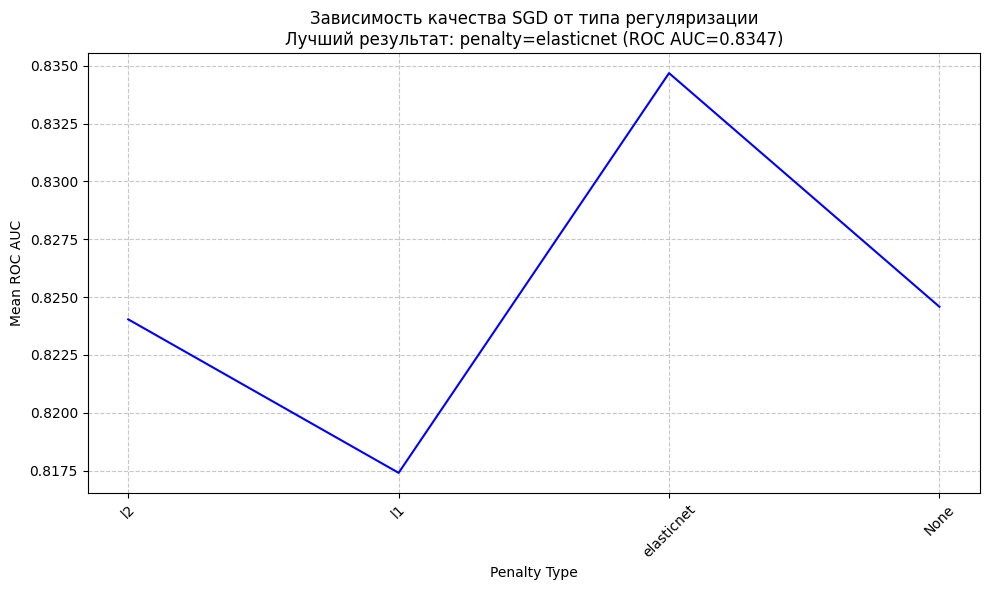

In [82]:
# среднее качество по всем loss для каждого penalty
x_SGD = [np.nanmean(list(graph_sgd[i].values())) for i in graph_sgd.keys()]

xTicks = list(graph_sgd.keys())

# лучший penalty
best_penalty_idx = np.argmax(x_SGD)
best_penalty_name = xTicks[best_penalty_idx]
best_score_val = x_SGD[best_penalty_idx]

plt.figure(figsize=(10, 6))
plt.plot(range(len(xTicks)), x_SGD, color='b', linestyle='-')
plt.xticks(range(len(xTicks)), xTicks, rotation=45)
plt.ylabel('Mean ROC AUC')
plt.xlabel('Penalty Type')
plt.title(f'Зависимость качества SGD от типа регуляризации\nЛучший результат: penalty={best_penalty_name} (ROC AUC={best_score_val:.4f})')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.3 RandomForestClassifier

- Инициализируем дефолтную модели (модель с дефолтными гиперпараметрами) и GridSearchCV для подбора гиперпараметров
- Подберем наилучшие параметры для модели с помощью GridSearchCV
- Построим график зависимости качества ROC-AUC от параметров

В подборе оптимальных параметров:
- Число деревьев (**n_estimators**) перебираем в диапазоне от 0 до 100
- Параметр максимального количества фичей для построения дерева (max_features) перебираем из \['auto', 'sqrt', 'log2', None\]
- Критерий разбиения на поддеревья (criterion) перебираем из \['gini', 'entropy'\]

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score

#### Сначала подберем оптимальное количество деревьев, зафиксируем, затем другие параметры

In [96]:
max_trees_number = 100
result = []
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1) # для способа 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    random_state=42
)

# Подсказка
for current_trees_number in range(1, max_trees_number):
    # инициализируем модель
    RFC_model = RandomForestClassifier(n_estimators=current_trees_number)
    # обучаем модель
    RFC_model.fit(X_train, y_train)
    # считаем скор
    score = roc_auc_score(y_test, RFC_model.predict_proba(X_test)[:,1])
    # сохраняем скор
    result.append(score)

c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\uti

In [97]:
best_trees_number = result.index(max(result))
best_roc_auc_rfc = max(result)
print(best_trees_number)
best_roc_auc_rfc

51


0.8896434999797759

In [98]:
res_rfc = {'Best model (n_estimators)': best_trees_number, 'Best ROC-AUC': best_roc_auc_rfc, 'max_features': 'default', 'criterion': 'default', 'Folds': 2}

In [99]:
# перебор параметров для RandomForestClassifier
res_rfc = {
    'Best model (n_estimators)': best_trees_number,
    'Best ROC-AUC': 0.0,
    'max_features': None,
    'criterion': None,
    'Folds': 0
}

for fold in range(3, 10):
    # сетка параметров
    param_grid = {
        'max_features': ['auto', 'sqrt', 'log2', None],
        'criterion': ['gini', 'entropy']
    }
    
    # базовая модель с фиксированным числом деревьев
    rfc_base = RandomForestClassifier(n_estimators=best_trees_number, random_state=42)
    
    # GridSearchCV с текущим количеством фолдов
    gs_rfc = GridSearchCV(
        estimator=rfc_base,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=fold, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # обучение на тренировочных данных
    gs_rfc.fit(X_train, y_train)  # X_train, y_train — ваши данные; если нет .values — уберите
    
    # оценка на тесте
    probas = gs_rfc.predict_proba(X_test)[:, 1]  # X_test — ваш тестовый набор
    test_score = roc_auc_score(y_test, probas)
    
    if test_score > res_rfc['Best ROC-AUC']:
        res_rfc['Best ROC-AUC'] = test_score
        res_rfc['Folds'] = fold
        
        # лучшие параметры из GridSearchCV
        best_params = gs_rfc.best_params_
        res_rfc['max_features'] = best_params.get('max_features')
        res_rfc['criterion'] = best_params.get('criterion')
        
        print(f"Новый лучший результат при fold={fold}:")
        print(f"  max_features: {res_rfc['max_features']}")
        print(f"  criterion: {res_rfc['criterion']}")
        print(f"  ROC AUC на тесте: {test_score:.6f}")

print("\n=== Итог по RFC ===")
print(f"Лучшее качество (ROC AUC на тесте): {res_rfc['Best ROC-AUC']:.6f}")
print(f"Достигнуто при числе фолдов: {res_rfc['Folds']}")
print(f"Лучшие параметры: max_features='{res_rfc['max_features']}', criterion='{res_rfc['criterion']}'")

c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  F

Новый лучший результат при fold=3:
  max_features: sqrt
  criterion: entropy
  ROC AUC на тесте: 0.885644


c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
8 fits failed out of a total of 32.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  F


=== Итог по RFC ===
Лучшее качество (ROC AUC на тесте): 0.885644
Достигнуто при числе фолдов: 3
Лучшие параметры: max_features='sqrt', criterion='entropy'


c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [100]:
res_rfc

{'Best model (n_estimators)': 51,
 'Best ROC-AUC': 0.8856441875985923,
 'max_features': 'sqrt',
 'criterion': 'entropy',
 'Folds': 3}

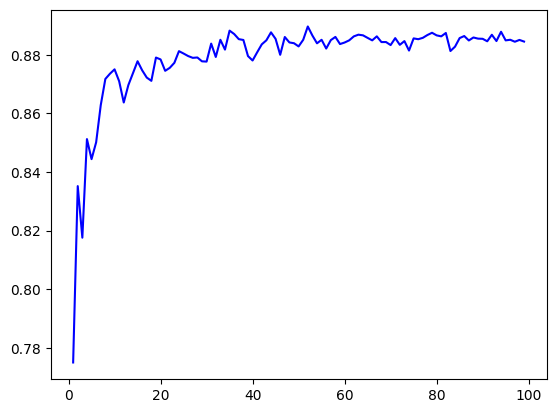

In [103]:
import pylab as pl
x_RFC = range(1, max_trees_number)
#xTicks = [...]
# rotation - поварьировать (это угол поворота названий категорий гиперпараметров)
#pl.xticks(range(...), xTicks, rotation=...)
pl.plot(x_RFC, result, color='b'); 
best_trees_number = 35 # После 35 деревьев ROC_AUC перестает значимо расти, поэтому взяли число деревьев = 35

Качество RFC стабилизируется после примерно 35 деревьев, дальнейший рост неэффективен. Лучшие параметры: max_features=None, criterion='entropy', ROC-AUC на тесте 0.8809

### 6. Ансамбль моделей

Попробуем "заблендить" модели (сложить результаты (ответы) разных алгоритмов) с разными коэффициентами перед ними

$$result(x) = clf_1(x) * \alpha + clf_2(x) * (1 - \alpha)$$

In [104]:
# Библиотека для блендинга
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

In [105]:
from sklearn.linear_model import SGDClassifier

In [106]:
sgd_fixed = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    random_state=42,
    max_iter=1000
)

In [107]:
sgd_fixed.fit(X, y)

c:\Users\Анастасия\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [113]:
# knn_best = gsCV.best_estimator_ # лучшая модель KNN после GridSearch
# # sgd_best = best_model_sgd # лучшая модель SGD после GridSearch

# # best_model_sgd = base_model_sgd.best_estimator_

# rf_best = RandomForestClassifier(
#     n_estimators=35,
#     max_features=res_rfc['max_features'], 
#     criterion=res_rfc['criterion'],
#     random_state=42,
#     n_jobs=-1
# )

# # ансамбль с исправленной моделью SGD
# ensemble_corrected = VotingClassifier(
#     estimators=[
#         ('knn', knn_best),
#         ('sgd', sgd_fixed),
#         ('rf', rf_best)
#     ],
#     voting='soft'
# )

# scores = cross_val_score(
#     ensemble_corrected,
#     X,
#     y,
#     scoring='roc_auc',
#     cv=5
# )

# print("ROC-AUC ансамбля:", scores.mean())
# print("Стандартное отклонение:", scores.std())

In [114]:
# Подготовка лучших моделей
knn_best = gsCV.best_estimator_

sgd_best = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    random_state=42,
    max_iter=1000
)

rf_best = RandomForestClassifier(
    n_estimators=35,
    max_features=res_rfc['max_features'],
    criterion=res_rfc['criterion'],
    random_state=42,
    n_jobs=-1
)

In [115]:
# проверяем обычный ансамбль с одинаковыми весами
ensemble = VotingClassifier(
    estimators=[
        ('knn', knn_best),
        ('sgd', sgd_best),
        ('rf', rf_best)
    ],
    voting='soft'
)

scores_ensemble = cross_val_score(
    ensemble,
    X,
    y,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

ensemble_auc = scores_ensemble.mean()
ensemble_std = scores_ensemble.std()

print(f"ROC-AUC ансамбля: {ensemble_auc:.4f}")
print(f"Стандартное отклонение: {ensemble_std:.4f}")

ROC-AUC ансамбля: 0.9007
Стандартное отклонение: 0.0034


_Каждая модель выдает вероятность:_

_$$ P(y=1|x) $$_

_и VotingClassifier усредняет эти вероятности._

_При одинаковых весах:_

$$ P_{ensemble} = \frac{ P_{KNN}+P_{SGD}+P_{RF} }{3} $$

_После этого уже по итоговой вероятности считается ROC-AUC_

_Для двух моделей можно проверить:_

$$ P = \alpha P_1+(1-\alpha)P_2 $$

_Например, для KNN + Random Forest:_

* α = 0 (только RF)
* α = 0.5 (равные веса)
* α = 1 (только KNN)

In [117]:
# KNN + SGD
alphas = np.arange(0, 1.1, 0.1)

knn_sgd_results = []

for alpha in alphas:
    model = VotingClassifier(
        estimators=[
            ('knn', knn_best),
            ('sgd', sgd_best)
        ],
        voting='soft',
        weights=[alpha, 1 - alpha]
    )
    
    scores = cross_val_score(
        model,
        X,
        y,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )
    
    knn_sgd_results.append(scores.mean())

best_idx = np.argmax(knn_sgd_results)

print(
    f"Лучший вес KNN: {alphas[best_idx]:.1f}, "
    f"вес SGD: {1 - alphas[best_idx]:.1f}"
)
print(f"ROC-AUC: {knn_sgd_results[best_idx]:.4f}")

Лучший вес KNN: 0.6, вес SGD: 0.4
ROC-AUC: 0.9011


In [118]:
# KNN + Random Forest
knn_rf_results = []

for alpha in alphas:
    model = VotingClassifier(
        estimators=[
            ('knn', knn_best),
            ('rf', rf_best)
        ],
        voting='soft',
        weights=[alpha, 1 - alpha]
    )
    
    scores = cross_val_score(
        model,
        X,
        y,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )
    
    knn_rf_results.append(scores.mean())

best_idx = np.argmax(knn_rf_results)

print(
    f"Лучший вес KNN: {alphas[best_idx]:.1f}, "
    f"вес RF: {1 - alphas[best_idx]:.1f}"
)
print(f"ROC-AUC: {knn_rf_results[best_idx]:.4f}")

Лучший вес KNN: 0.8, вес RF: 0.2
ROC-AUC: 0.8993


In [119]:
# SGD + Random Forest
sgd_rf_results = []

for alpha in alphas:
    model = VotingClassifier(
        estimators=[
            ('sgd', sgd_best),
            ('rf', rf_best)
        ],
        voting='soft',
        weights=[alpha, 1 - alpha]
    )
    
    scores = cross_val_score(
        model,
        X,
        y,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )
    
    sgd_rf_results.append(scores.mean())

best_idx = np.argmax(sgd_rf_results)

print(
    f"Лучший вес SGD: {alphas[best_idx]:.1f}, "
    f"вес RF: {1 - alphas[best_idx]:.1f}"
)
print(f"ROC-AUC: {sgd_rf_results[best_idx]:.4f}")

Лучший вес SGD: 0.8, вес RF: 0.2
ROC-AUC: 0.8987


Переберем для трех моделей веса с шагом 0.1 при условии:
w_KNN + w_SGD + w_RF = 1

In [120]:
weights_results = []

for w_knn in np.arange(0, 1.1, 0.1):
    for w_sgd in np.arange(0, 1.1 - w_knn, 0.1):
        w_rf = round(1 - w_knn - w_sgd, 1)
        
        model = VotingClassifier(
            estimators=[
                ('knn', knn_best),
                ('sgd', sgd_best),
                ('rf', rf_best)
            ],
            voting='soft',
            weights=[w_knn, w_sgd, w_rf]
        )
        
        scores = cross_val_score(
            model,
            X,
            y,
            scoring='roc_auc',
            cv=5,
            n_jobs=-1
        )
        
        weights_results.append({
            'KNN': w_knn,
            'SGD': w_sgd,
            'RF': w_rf,
            'ROC-AUC': scores.mean()
        })

In [121]:
weights_df = pd.DataFrame(weights_results)

best_ensemble = weights_df.loc[
    weights_df['ROC-AUC'].idxmax()
]

print("Лучшие веса:")
print(best_ensemble)

Лучшие веса:
KNN        0.500000
SGD        0.400000
RF         0.100000
ROC-AUC    0.902323
Name: 49, dtype: float64


Лучший результат среди рассмотренных ансамблей получен при весах KNN = 0.5, SGD = 0.4 и Random Forest = 0.1. ROC-AUC составил 0.9023, что примерно на 0.0062 выше результата лучшей отдельной модели SGD (ROC-AUC = 0.8961). 
Следовательно, в рамках проведенного эксперимента объединение моделей позволило дополнительно повысить качество классификации. Итоговый ансамбль использован для решения поставленной задачи бинарной классификации — определения, превышает ли средний заработок человека порог $50k.

### 7. Вывод

В работе решалась задача бинарной классификации: определить, превышает ли средний заработок человека порог $50k. Основной метрикой качества выступал ROC-AUC.

Были рассмотрены и настроены модели KNN, SGD и Random Forest. Для моделей выполнен подбор гиперпараметров и оценка качества с использованием кросс-валидации. Для Random Forest дополнительно исследована зависимость ROC-AUC от количества деревьев; после примерно 35 деревьев прирост качества становится незначительным, поэтому для дальнейшего моделирования было выбрано n_estimators = 35.

На заключительном этапе были исследованы ансамбли моделей с использованием soft voting и различных весов. Наилучший результат показал ансамбль из KNN, SGD и Random Forest с весами 0.5, 0.4 и 0.1 соответственно. Его ROC-AUC составил 0.9023.

Таким образом, в рамках проведенного эксперимента объединение нескольких алгоритмов позволило повысить качество классификации по сравнению с отдельными моделями. Полученный ансамбль выбран в качестве итоговой модели для прогнозирования принадлежности наблюдения к классу с доходом выше $50k.